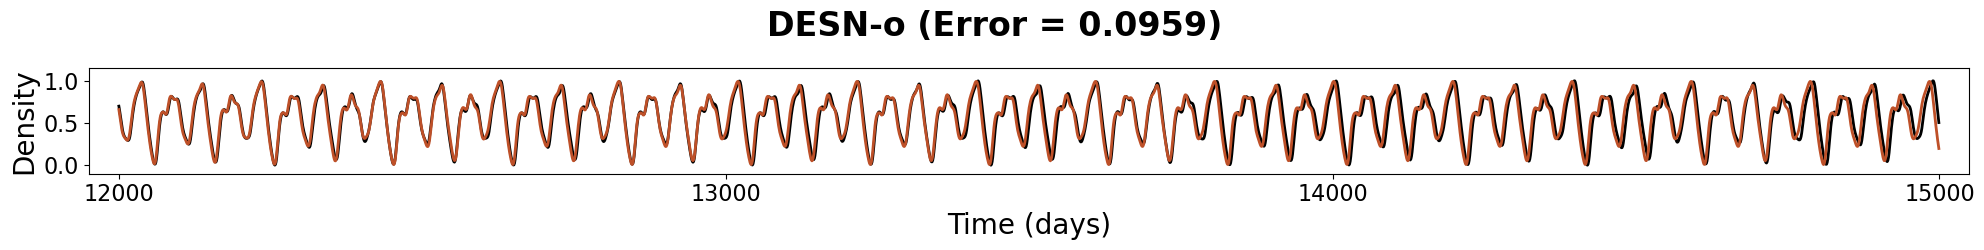

In [1]:
import numpy as np
import scipy.io as sio
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt


# ---------------------------------------------------------------------
# Load data
dataset = sio.loadmat("Data/MG.mat")
data = dataset["MG"].squeeze()
step = 1
index = np.arange(0, len(data), step)
inputs = data[index].reshape(1, -1)
num_inputs, len_data = inputs.shape 
time = np.arange(len_data)
num_outputs = 1

# ---------------------------------------------------------------------
# Extracting Parameters
display = True
sample_rate_thresh = 0.5

w_in_scale1 = 0.16703
w_in_scale2 = 0.15812

bias = 1
washout_length = 1000

pr_in = 0.13471
pr_out = 0.1539

spectral_radius1 = 1.004
spectral_radius2 = 1.1576
spectral_radius3 = 0.94438
spectral_radius4 = 0.84442
spectral_radius5 = 0.83254

split_ratio = 0.8

reservoir_size1 = 128
reservoir_size2 = 96
reservoir_size3 = 64
reservoir_size4 = 48
reservoir_size5 = 32

leaking_rate1 = 0.56763
leaking_rate2 = 0.70261
leaking_rate3 = 0.79704
leaking_rate4 = 0.95362
leaking_rate5 = 0.99598

lambda_ = 1e-5

func_state = np.tanh
func_active = np.tanh

target_index = 0

seed = 1377
np.random.seed(seed)

# ---------------------------------------------------------------------
# Splitting Data
train_length = int(np.floor(split_ratio * len_data))
test_length = len_data - train_length

pretrain_index = np.arange(0, washout_length)
train_index = np.arange(washout_length, train_length)
test_index = np.arange(train_length, train_length + test_length)

# ---------------------------------------------------------------------
# Helper functions

def matlab_sprand(m, n, density):
    return sp.random(
        m,
        n,
        density=density,
        format="csr",
        data_rvs=np.random.rand
    )


def center_nonzero_sparse_matrix(A):
    A = A.copy().tocsr()
    A.data = A.data - 0.5
    return A


def scale_to_spectral_radius(A, desired_radius):
    eigval = spla.eigs(A, k=1, which="LM", return_eigenvectors=False)[0]
    current_radius = np.abs(eigval)
    return A * (desired_radius / current_radius)


# ---------------------------------------------------------------------
# Constructing the Five-Layer Network

w_in = (
    np.random.rand(reservoir_size1, num_inputs + bias) - 0.5
) * np.array([[w_in_scale1, w_in_scale2]])

w_res1 = matlab_sprand(reservoir_size1, reservoir_size1, pr_in)
w_res1 = center_nonzero_sparse_matrix(w_res1)
w_res1 = scale_to_spectral_radius(w_res1, spectral_radius1)

w_inter1 = matlab_sprand(reservoir_size2, reservoir_size1, pr_out)
w_inter1 = center_nonzero_sparse_matrix(w_inter1)

w_in2 = (
    np.random.rand(reservoir_size2, num_inputs + bias) - 0.5
) * np.array([[w_in_scale1, w_in_scale2]])

w_res2 = matlab_sprand(reservoir_size2, reservoir_size2, pr_in)
w_res2 = center_nonzero_sparse_matrix(w_res2)
w_res2 = scale_to_spectral_radius(w_res2, spectral_radius2)

w_inter2 = matlab_sprand(reservoir_size3, reservoir_size2, pr_out)
w_inter2 = center_nonzero_sparse_matrix(w_inter2)

w_in3 = (
    np.random.rand(reservoir_size3, num_inputs + bias) - 0.5
) * np.array([[w_in_scale1, w_in_scale2]])

w_res3 = matlab_sprand(reservoir_size3, reservoir_size3, pr_in)
w_res3 = center_nonzero_sparse_matrix(w_res3)
w_res3 = scale_to_spectral_radius(w_res3, spectral_radius3)

w_inter3 = matlab_sprand(reservoir_size4, reservoir_size3, pr_out)
w_inter3 = center_nonzero_sparse_matrix(w_inter3)

w_in4 = (
    np.random.rand(reservoir_size4, num_inputs + bias) - 0.5
) * np.array([[w_in_scale1, w_in_scale2]])

w_res4 = matlab_sprand(reservoir_size4, reservoir_size4, pr_in)
w_res4 = center_nonzero_sparse_matrix(w_res4)
w_res4 = scale_to_spectral_radius(w_res4, spectral_radius4)

w_inter4 = matlab_sprand(reservoir_size5, reservoir_size4, pr_out)
w_inter4 = center_nonzero_sparse_matrix(w_inter4)

w_in5 = (
    np.random.rand(reservoir_size5, num_inputs + bias) - 0.5
) * np.array([[w_in_scale1, w_in_scale2]])

w_res5 = matlab_sprand(reservoir_size5, reservoir_size5, pr_in)
w_res5 = center_nonzero_sparse_matrix(w_res5)
w_res5 = scale_to_spectral_radius(w_res5, spectral_radius5)

# ---------------------------------------------------------------------
# Running the Network

state_dim = (
    + reservoir_size1
    + reservoir_size2
    + reservoir_size3
    + reservoir_size4
    + reservoir_size5
)

states = np.zeros((state_dim, train_length - washout_length))

target = inputs[target_index, washout_length + 1:train_length + 1].reshape(1, -1)

state1 = np.zeros((reservoir_size1, 1))
state2 = np.zeros((reservoir_size2, 1))
state3 = np.zeros((reservoir_size3, 1))
state4 = np.zeros((reservoir_size4, 1))
state5 = np.zeros((reservoir_size5, 1))

for t in range(1, train_length + 1):
    u = inputs[:, [t - 1]]

    if bias:
        u = np.vstack((np.ones((1, 1)), u))

    state1 = (
        (1 - leaking_rate1) * func_state(state1)
        + leaking_rate1 * func_active(w_in @ u + w_res1 @ state1)
    )

    state2 = (
        (1 - leaking_rate2) * func_state(state2)
        + leaking_rate2 * func_active(w_inter1 @ state1 + w_res2 @ state2)
    )

    state3 = (
        (1 - leaking_rate3) * func_state(state3)
        + leaking_rate3 * func_active(w_inter2 @ state2 + w_res3 @ state3)
    )

    state4 = (
        (1 - leaking_rate4) * func_state(state4)
        + leaking_rate4 * func_active(w_inter3 @ state3 + w_res4 @ state4)
    )

    state5 = (
        (1 - leaking_rate5) * func_state(state5)
        + leaking_rate5 * func_active(w_inter4 @ state4 + w_res5 @ state5)
    )

    if t > washout_length:
        states[:, [t - washout_length - 1]] = np.vstack(
            (state1, state2, state3, state4, state5)
        )

# ---------------------------------------------------------------------
# Training Readout Layer

w_out = np.linalg.solve(
    states @ states.T + lambda_ * np.eye(states.shape[0]),
    states @ target.T
)

# ---------------------------------------------------------------------
# Prediction Phase

test_states = np.zeros((num_outputs, test_length))
u = inputs[:, [train_length]]

for t in range(1, test_length + 1):
    if bias:
        u = np.vstack((np.ones((1, 1)), u))

    state1 = (
        (1 - leaking_rate1) * func_state(state1)
        + leaking_rate1 * func_active(w_in @ u + w_res1 @ state1)
    )

    state2 = (
        (1 - leaking_rate2) * func_state(state2)
        + leaking_rate2 * func_active(w_inter1 @ state1 + w_res2 @ state2)
    )

    state3 = (
        (1 - leaking_rate3) * func_state(state3)
        + leaking_rate3 * func_active(w_inter2 @ state2 + w_res3 @ state3)
    )

    state4 = (
        (1 - leaking_rate4) * func_state(state4)
        + leaking_rate4 * func_active(w_inter3 @ state3 + w_res4 @ state4)
    )

    state5 = (
        (1 - leaking_rate5) * func_state(state5)
        + leaking_rate5 * func_active(w_inter4 @ state4 + w_res5 @ state5)
    )

    y = w_out.T @ np.vstack((state1, state2, state3, state4, state5))

    y = np.minimum(np.maximum(y, 0), 1)

    test_states[:, [t - 1]] = y

    if t == test_length:
        break

    u = inputs[:, [train_length + t]]
    u[target_index, :] = y

# ---------------------------------------------------------------------
# Evaluating Error

err = np.sqrt(np.mean((inputs[target_index, test_index].reshape(1, -1) - test_states) ** 2))
#print(err)

test_data = data[test_index]
pred = test_states.squeeze()
test_time = time[test_index]

# ---------------------------------------------------------------------
# Plotting

color1 = np.array([55, 125, 200]) / 255
color2 = np.array([190, 80, 40]) / 255
color3 = np.array([240, 180, 60]) / 255
color4 = np.array([120, 50, 140]) / 255

fig, ax = plt.subplots(figsize=(20, 2.5))

fig.suptitle(
    f"DESN-o (Error = {err:.4f})",
    fontsize=24,
    fontweight="bold"
)

ax.plot(test_time, test_data, color="black", linewidth=2)
ax.plot(test_time, pred, color=color2, linewidth=2)

x_start = test_time[0] - 50
x_end = test_time[-1] + 50

ax.set_ylim([-0.1, 1.15])
ax.set_xlim([x_start, x_end])

ax.set_xticks(np.linspace(12000, 15000, 4))
ax.ticklabel_format(style="plain", axis="x", useOffset=False)

ax.set_yticks(np.arange(0, 1.01, 0.5))

ax.set_xlabel("Time (days)",fontsize = 20)
ax.set_ylabel("Density", fontsize = 20)

ax.tick_params(labelsize=16)

for spine in ax.spines.values():
    spine.set_visible(True)

plt.tight_layout()

#plt.savefig("...", dpi=300, bbox_inches="tight")